In [ ]:
import numpy as np                                                   # numerical computing library
import matplotlib.pyplot as plt                                      # plotting library
import scipy.integrate as spi                                        # scientific library — ODE solvers
import os                                                            # operating system interface
os.chdir(r'C:/Users/Giannis/.vscode/03_pharmacokinetics_simulator')  # set working directory

def one_compartment(t, C, ke):
    # ODE function — kept for reference but not used in loop
    dCdt = -ke * C[0]   # first order elimination
    return [dCdt]

# Parameters
ke = 0.15        # elimination rate constant (1/hour)
dose = 46.0      # drug dose per administration (mg/L)
interval = 10.0  # hours between doses
n_doses = 6      # total number of doses
C_min = 10.0     # minimum effective concentration (mg/L)
C_max = 60.0     # maximum safe concentration (mg/L)

# Simulate dose by dose using analytical solution
t_total = []
C_total = []
C_current = 0.0  # start with no drug in body

for i in range(n_doses):
    # time points for this interval (starting from 0)
    t_eval_dose = np.linspace(0, interval, 500)

    C_current += dose   # add new dose to current concentration

    # analytical solution / exact, instant, no solver needed like RK45
    C_interval = C_current * np.exp(-ke * t_eval_dose)

    t_total.extend(t_eval_dose + i * interval)   # shift time correctly
    C_total.extend(C_interval)                   # store concentrations
    C_current = C_interval[-1]                   # end concentration for next dose

t_total = np.array(t_total)
C_total = np.array(C_total)

# Key metrics
time_in_window = np.sum((C_total >= C_min) &
                         (C_total <= C_max)) / len(C_total) * 100
time_above_max = np.sum(C_total > C_max) / len(C_total) * 100
time_below_min = np.sum(C_total < C_min) / len(C_total) * 100

print(f'Time in therapeutic window: {time_in_window:.1f}%')
print(f'Time above maximum safe:    {time_above_max:.1f}%')
print(f'Time below effective:       {time_below_min:.1f}%')

Time in therapeutic window: 100.0%
Time above maximum safe:    0.0%
Time below effective:       0.0%


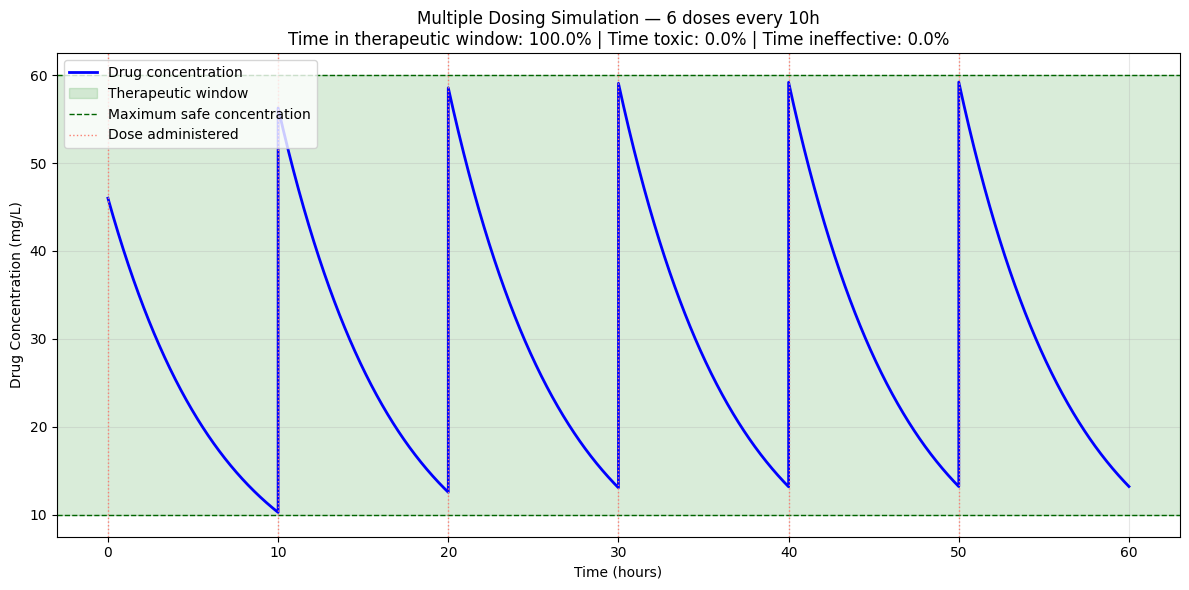

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(t_total, C_total, color='blue', linewidth=2, label='Drug concentration')                      # concentration over all doses
plt.axhspan(C_min, C_max, alpha=0.15, color='green', label='Therapeutic window')                       # shade safe zone
plt.axhline(C_min, color='darkgreen', linestyle='--', linewidth=1)                                     # minimum effective line
plt.axhline(C_max, color='darkgreen', linestyle='--', linewidth=1, label='Maximum safe concentration') # toxic level line

# mark each dose administration with a vertical line
for i in range(n_doses):
    plt.axvline(i * interval, color='salmon',
                linestyle=':', linewidth=1,
                label='Dose administered' if i == 0 else '')  # label only first

plt.xlabel('Time (hours)')
plt.ylabel('Drug Concentration (mg/L)')
plt.title(f'Multiple Dosing Simulation — {n_doses} doses every {interval}h\n'
          f'Time in therapeutic window: {time_in_window:.1f}% | '
          f'Time toxic: {time_above_max:.1f}% | '
          f'Time ineffective: {time_below_min:.1f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/03_multiple_dosing.png', bbox_inches='tight')  # save to results
plt.show()

Optimal dosing interval: 10.0 hours
Maximum time in window:  100.0%


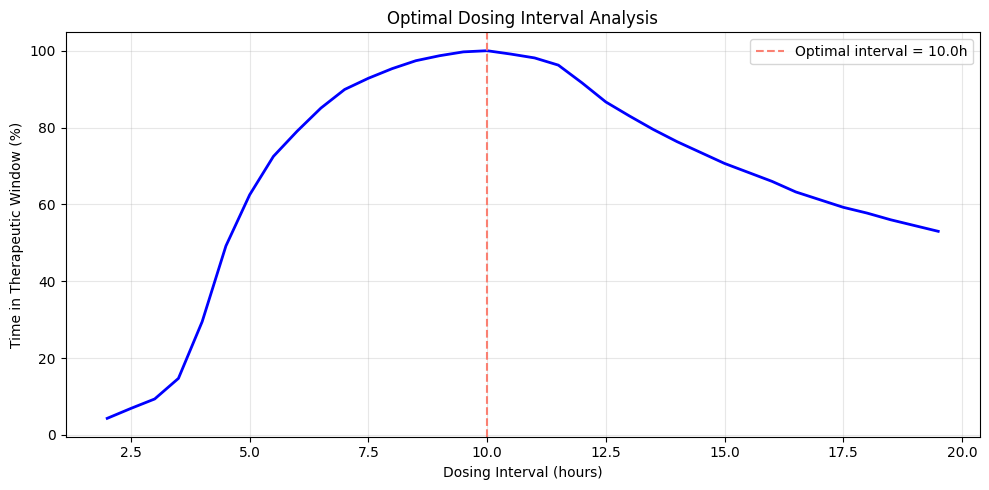

In [ ]:
# Find the optimal dosing interval that maximizes time in therapeutic window

intervals = np.arange(2, 20, 0.5)   # test intervals from 2h to 20h
time_in_window_list = []             # store % therapeutic window per interval

for interval_test in intervals:
    n_doses_test = int(48 / interval_test)  # doses that fit in 48h
    t_test = []
    C_test = []
    C_curr = 0.0    # start with no drug

    for i in range(n_doses_test):
        # time points for this interval
        t_eval_test = np.linspace(0, interval_test, 200) # type: ignore

        C_curr += dose  # add new dose

        # analytical solution — no ODE solver needed!
        # C(t) = C0 * e^(-ke*t) — exact solution to first order ODE
        C_interval = C_curr * np.exp(-ke * t_eval_test)

        t_test.extend(t_eval_test + i * interval_test)   # shift time
        C_test.extend(C_interval)                        # store concentrations
        C_curr = C_interval[-1]                          # end concentration

    C_test = np.array(C_test)

    pct = np.sum((C_test >= C_min) &
                  (C_test <= C_max)) / len(C_test) * 100
    time_in_window_list.append(pct)

optimal_interval = intervals[np.argmax(time_in_window_list)]
print(f'Optimal dosing interval: {optimal_interval:.1f} hours')
print(f'Maximum time in window:  {max(time_in_window_list):.1f}%')

plt.figure(figsize=(10, 5))
plt.plot(intervals, time_in_window_list,
         color='blue', linewidth=2)

plt.axvline(optimal_interval, color='salmon', linestyle='--',
            label=f'Optimal interval = {optimal_interval:.1f}h')

plt.xlabel('Dosing Interval (hours)')
plt.ylabel('Time in Therapeutic Window (%)')
plt.title('Optimal Dosing Interval Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/03_optimal_dosing.png', bbox_inches='tight')
plt.show()

In [8]:
# Test different doses and find the largest valid interval for each
test_doses = [30.0, 40.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 55.0, 60.0]

print(f'{"Dose (mg/L)":<15} {"Best interval (h)":<20} {"Max time in window":<20}')
print('-' * 55)

for test_dose in test_doses:
    time_in_window_list_test = []

    for interval_test in intervals:
        n_doses_test = int(48 / interval_test)
        t_test = []
        C_test = []
        C_curr = 0.0

        for i in range(n_doses_test):
            t_eval_test = np.linspace(0, interval_test, 200)
            C_curr += test_dose
            C_interval_test = C_curr * np.exp(-ke * t_eval_test)
            t_test.extend(t_eval_test + i * interval_test)
            C_test.extend(C_interval_test)
            C_curr = C_interval_test[-1]

        C_test = np.array(C_test)
        pct = np.sum((C_test >= C_min) &
                      (C_test <= C_max)) / len(C_test) * 100
        time_in_window_list_test.append(pct)

    # find largest interval achieving 100%
    valid = [inv for inv, pct in zip(intervals, time_in_window_list_test)
             if pct >= 99.9]
    best = max(valid) if valid else 0
    best_pct = max(time_in_window_list_test)
    print(f'{test_dose:<15} {best:<20} {best_pct:.1f}%')

Dose (mg/L)     Best interval (h)    Max time in window  
-------------------------------------------------------
30.0            7.0                  100.0%
40.0            9.0                  100.0%
45.0            10.0                 100.0%
46.0            10.0                 100.0%
47.0            0                    99.9%
48.0            0                    99.8%
49.0            0                    99.1%
50.0            0                    98.5%
55.0            0                    95.4%
60.0            0                    92.8%
